# Simulate populations with spontaneus creation
## Part 4


In [11]:
# Import required modules
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
import random
import collections

In [80]:
def trial(chance):
    """ Returns the boolean outcome of a trial given it's chance of success."""

    return random.random() <= chance


class entity():
    """ The entity object represents a live entity."""
    
    def __init__(self):
        self.period = 0
    
    def __repr__(self):
        return str(self.period)

    def __call__(self):
        self.period += 1
        return self


class environment():
    """ The environment tracks the population and parameters of the simulation."""

    def __init__(self, birth_rate, death_chance):
        self.birth_rate = birth_rate
        self.death_chance = death_chance
        self.population = []
        self.history = []
        self.mortuary = collections.Counter()

    def __call__(self):

        for i, e in enumerate(self.population):
            e()
            if trial(self.death_chance):
                self.mortuary.update([self.population.pop(i).period])

        self.population.append(entity())
        self.history.append(len(self.population))

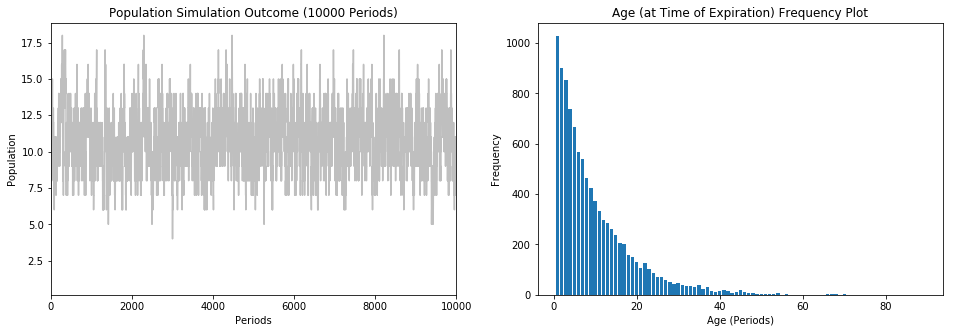

In [119]:
def run_sim(birth_rate, death_chance, n_periods):
    """ Run simulation of environment n times and plot the result"""

    # Set up plot.
    fig, ax = plt.subplots(1, 2, figsize=(16,5))
    ax[0].set(
        title=f"Population Simulation Outcome ({n_periods} Periods)",
        xlabel="Periods",
        ylabel="Population",
        xlim=(0, n_periods)
    )
    ax[1].set(
        title=f"Age (at Time of Expiration) Frequency Plot",
        xlabel="Age (Periods)",
        ylabel="Frequency",
    )

    # Run simulation n times.
    env = environment(birth_rate, death_chance)
    for period in range(0, n_periods):
        env()

    # Line graph of population over time
    ax[0].plot(env.history, color=[.5, .5, .5, .5])

    # Frequency bar chart of population age at expiration of entity
    age, deaths = tuple(zip(*sorted(env.mortuary.items(), key=lambda x: x[0])))
    ax[1].bar(age, deaths)

# Run the simulation n times.
run_sim(1, .1, 10000)